In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
#load dataset
df = pd.read_csv('dataset.csv') 

In [3]:
# Cek data awal
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# Cek missing value
print(df.isnull().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [5]:
#data cleaning
df = df.dropna()
df = df.drop(columns=['track_id', 'artists', 'album_name'], errors='ignore')

# 🔥 FIX PENTING (BIAR MATCH)
df['track_name'] = df['track_name'].astype(str).str.strip().str.lower()

In [6]:
#Filter Genre
selected_genres = [
    'pop',
    'metal',
    'jazz',
    'rock',
    'reggae',
    'hip-hop',
    'edm'
]

# Ambil hanya genre yang dipilih
df = df[df['track_genre'].isin(selected_genres)]

# Reset index
df = df.reset_index(drop=True)

# Cek hasil distirbusi
print(df['track_genre'].value_counts())


track_genre
edm        1000
hip-hop    1000
jazz       1000
metal      1000
pop        1000
reggae     1000
rock       1000
Name: count, dtype: int64


In [7]:
#Fitur Selection
fitur = [
    'danceability','energy','loudness',
    'speechiness','acousticness',
    'instrumentalness','liveness',
    'valence','tempo'
]

In [8]:
#Encoding Genre
le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['track_genre'])

X = df[fitur]
y = df['genre_encoded']

In [9]:
#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
#Training RF
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

df['predicted_genre'] = rf.predict(X)
df['predicted_genre_label'] = le.inverse_transform(df['predicted_genre'])

In [11]:
#Normalisasi
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=fitur, index=df.index)

In [12]:
#Rekomendasi
def rekomendasi_lagu(judul_lagu, top_n=5, use_filter=True):

    judul_lagu = str(judul_lagu).strip().lower()

    if judul_lagu not in set(df['track_name']):
        return "Lagu tidak ditemukan di dataset"

    idx = df[df['track_name'] == judul_lagu].index[0]

    genre = df.loc[idx, 'predicted_genre']

    if use_filter:
        df_filter = df[df['predicted_genre'] == genre]
        df_filter_scaled = df_scaled.loc[df_filter.index]
    else:
        df_filter = df
        df_filter_scaled = df_scaled

    sim = cosine_similarity([df_scaled.loc[idx]], df_filter_scaled)

    sim_scores = list(enumerate(sim[0]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:]

    hasil = []
    sudah_ada = set()

    for i in sim_scores:

        idx_lagu = df_filter.iloc[i[0]].name
        nama_lagu = df.loc[idx_lagu, 'track_name']

        if nama_lagu not in sudah_ada:

            hasil.append({
                'track_name': nama_lagu,
                'genre': df.loc[idx_lagu, 'predicted_genre_label'],
                'similarity': round(i[1], 4)
            })

            sudah_ada.add(nama_lagu)

        if len(hasil) == top_n:
            break

    return pd.DataFrame(hasil)

In [13]:
# evaluasi

def evaluasi_sistem(data):

    def eval_k(k):

        total_precision = 0
        total_recall = 0
        valid = 0

        for idx in range(len(data)):

            judul = data.iloc[idx]['track_name']

            rec = rekomendasi_lagu(
                judul,
                top_n=100,
                use_filter=True
            )

            if isinstance(rec, str):
                continue

            precision_k = rec.head(k)['similarity'].mean()

            total_similarity = rec['similarity'].sum()

            if total_similarity > 0:
                recall_k = (
                    rec.head(k)['similarity'].sum()
                    /
                    total_similarity
                )
            else:
                recall_k = 0

            total_precision += precision_k
            total_recall += recall_k

            valid += 1

        if valid == 0:
            return 0, 0

        avg_precision = total_precision / valid
        avg_recall = total_recall / valid

        return avg_precision, avg_recall

    # ======================
    # TOP 10
    # ======================
    p10, r10 = eval_k(10)

    # ======================
    # TOP 30
    # ======================
    p30, r30 = eval_k(30)

    # ======================
    # TOP 50
    # ======================
    p50, r50 = eval_k(50)

    print("=== Evaluasi Sistem Rekomendasi ===\n")

    print(f"Precision@10 : {p10:.4f}")
    print(f"Recall@10    : {r10:.4f}\n")

    print(f"Precision@30 : {p30:.4f}")
    print(f"Recall@30    : {r30:.4f}\n")

    print(f"Precision@50 : {p50:.4f}")
    print(f"Recall@50    : {r50:.4f}")

    # ======================
    # VISUALISASI
    # ======================

    import matplotlib.pyplot as plt
    import numpy as np

    labels = ['Top-10', 'Top-30', 'Top-50']

    precision = [p10, p30, p50]
    recall = [r10, r30, r50]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(10,6))

    bar1 = plt.bar(
        x - width/2,
        precision,
        width,
        label='Precision'
    )

    bar2 = plt.bar(
        x + width/2,
        recall,
        width,
        label='Recall'
    )

    plt.ylabel('Skor Evaluasi')
    plt.xlabel('Evaluasi Top-K')
    plt.ylim(0,1)
    plt.xticks(x, labels)

    # Nilai di atas batang
    for bar in bar1:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f'{h:.3f}',
            ha='center'
        )

    for bar in bar2:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f'{h:.3f}',
            ha='center'
        )

    plt.legend()
    plt.title('Hasil Evaluasi Sistem Rekomendasi')
    plt.tight_layout()
    plt.show()

    return (
        p10, r10,
        p30, r30,
        p50, r50
    )

In [14]:
judul = "something in the way"

rec = rekomendasi_lagu(judul, top_n=100, use_filter=True)
print(rec)

                             track_name genre  similarity
0             imagine - remastered 2010  rock      0.9795
1                   hope for the future  rock      0.9720
2                       love is a bitch  rock      0.9719
3                          i'll be good  rock      0.9681
4                         be my mistake  rock      0.9679
..                                  ...   ...         ...
95                  just maath maathali  rock      0.8411
96  bohemian rhapsody - remastered 2011  rock      0.8408
97                       transito lento  rock      0.8398
98               sympathy for the devil  rock      0.8397
99                   me hace tanto bien  rock      0.8396

[100 rows x 3 columns]


=== Evaluasi Sistem Rekomendasi ===

Precision@10 : 0.9915
Recall@10    : 0.1015

Precision@30 : 0.9866
Recall@30    : 0.3030

Precision@50 : 0.9832
Recall@50    : 0.5033


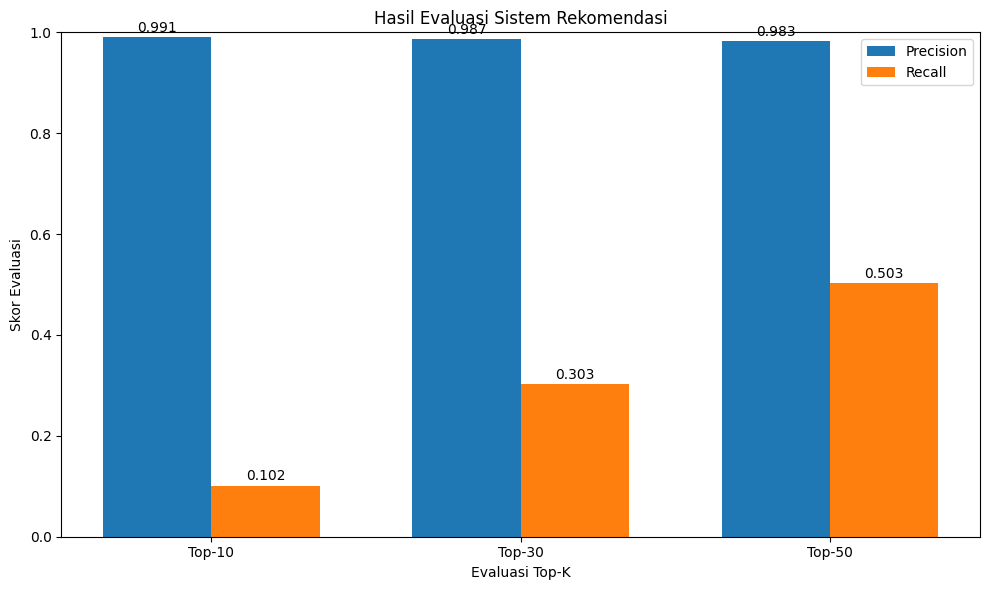

(np.float64(0.9914730657142876),
 np.float64(0.10153071689384786),
 np.float64(0.9865531957142869),
 np.float64(0.303049034686266),
 np.float64(0.9832125234285698),
 np.float64(0.5033346740339929))

In [15]:
evaluasi_sistem(df)

=== Evaluasi Random Forest ===
Accuracy : 0.646
Precision: 0.645
Recall   : 0.646
F1-score : 0.644

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.73      0.71       203
           1       0.54      0.47      0.50       224
           2       0.87      0.88      0.87       178
           3       0.76      0.80      0.78       215
           4       0.44      0.50      0.47       183
           5       0.60      0.58      0.59       211
           6       0.61      0.59      0.60       186

    accuracy                           0.65      1400
   macro avg       0.65      0.65      0.65      1400
weighted avg       0.64      0.65      0.64      1400



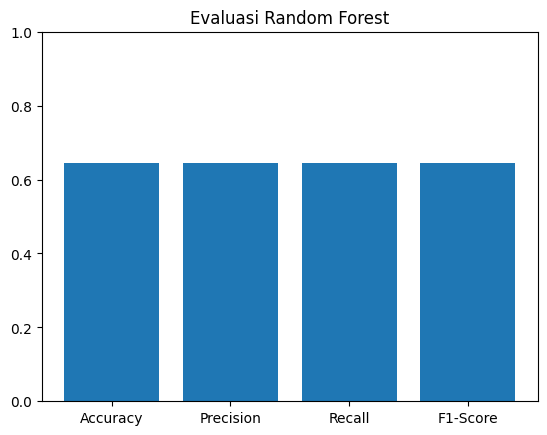

In [16]:
# =========================
# EVALUASI RANDOM FOREST
# =========================

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred, average='weighted')
recall_rf = recall_score(y_test, y_pred, average='weighted')
f1_rf = f1_score(y_test, y_pred, average='weighted')

print("=== Evaluasi Random Forest ===")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision_rf, 3))
print("Recall   :", round(recall_rf, 3))
print("F1-score :", round(f1_rf, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# VISUALISASI (OPSIONAL UNTUK SKRIPSI)
# =========================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision_rf, recall_rf, f1_rf]

plt.figure()
plt.bar(metrics, values)
plt.title("Evaluasi Random Forest")
plt.ylim(0, 1)
plt.show()